<a href="https://colab.research.google.com/github/Lakshmi-krishna-vr/Computational_Optimization_/blob/main/assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##                                                      ASSIGNMENT

##Environment Setup & Image Loading

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, img_as_float
from scipy import ndimage
from collections import defaultdict
import time
import urllib.request

def load_sample_image():
    """Loads a sample grayscale medical image for testing."""
    # Downloading a sample chest X-ray from a public URL for Colab testing
    url = "https://upload.wikimedia.org/wikipedia/commons/thumb/c/c8/Chest_Xray_PA_3-08mm.jpg/512px-Chest_Xray_PA_3-08mm.jpg"
    urllib.request.urlretrieve(url, "sample_xray.jpg")
    img = io.imread("sample_xray.jpg")
    if len(img.shape) >= 3:
        img = color.rgb2gray(img)
    return img_as_float(img)

print("Libraries imported successfully.")

Libraries imported successfully.


##Disjoint Set Forest (Union-Find) Logic

## The Graph Logic
The code treats the image as a graph $G = (V, E)$.$V$ (Vertices): Every pixel is a node.$E$ (Edges): Every pixel is connected to its neighbor.$w(e_i)$ (Weight): The weight of the edge connecting two pixels is the absolute difference in their intensity:$$w(e_{u,v}) = |I(u) - I(v)|$$Where $I(u)$ is the brightness of pixel $u$.

##The Internal Variation($Int$)
 For any group of pixels (a "component" $C$), the algorithm tracks the Internal Variation. This is the weight of the strongest link in that group's Minimum Spanning Tree (the "cheapest" way to connect all pixels in that group):$$Int(C) = \max_{e \in MST(C)} w(e)$$

 ##The Threshold Function ($\tau$)
 Because small groups don't have many edges yet, $Int(C)$ starts at zero. To prevent the algorithm from making millions of tiny groups, we add a Threshold Function based on your $k$ parameter:$$\tau(C) = \frac{k}{|C|}$$

In [2]:

class UnionFind:
    def __init__(self, num_elements):
        self.parent = np.arange(num_elements)
        self.size = np.ones(num_elements, dtype=int)
        self.max_weight = np.zeros(num_elements, dtype=float)

    def find(self, i):
        if self.parent[i] == i:
            return i
        self.parent[i] = self.find(self.parent[i])
        return self.parent[i]

    def union(self, i, j, weight):
        root_i = self.find(i)
        root_j = self.find(j)
        if root_i != root_j:
            if self.size[root_i] < self.size[root_j]:
                root_i, root_j = root_j, root_i

            self.parent[root_j] = root_i
            self.size[root_i] += self.size[root_j]

            self.max_weight[root_i] = max(self.max_weight[root_i], self.max_weight[root_j], weight)

## Graph Construction & Segmentation Algorithm

$$MInt(C_1, C_2) = \min(Int(C_1) + \tau(C_1), Int(C_2) + \tau(C_2))$$

In [3]:

def segment_image_optimized(image, k=0.05):
    rows, cols = image.shape
    num_pixels = rows * cols

    diff_h = np.abs(image[:, :-1] - image[:, 1:])
    idx_h1 = np.arange(num_pixels).reshape(rows, cols)[:, :-1].flatten()
    idx_h2 = np.arange(num_pixels).reshape(rows, cols)[:, 1:].flatten()
    edges_h = np.column_stack((diff_h.flatten(), idx_h1, idx_h2))


    diff_v = np.abs(image[:-1, :] - image[1:, :])
    idx_v1 = np.arange(num_pixels).reshape(rows, cols)[:-1, :].flatten()
    idx_v2 = np.arange(num_pixels).reshape(rows, cols)[1:, :].flatten()
    edges_v = np.column_stack((diff_v.flatten(), idx_v1, idx_v2))

    edges = np.vstack((edges_h, edges_v))
    edges = edges[edges[:, 0].argsort()]

    uf = UnionFind(num_pixels)

    for row in edges:
        weight, u, v = row[0], int(row[1]), int(row[2])
        root_u = uf.find(u)
        root_v = uf.find(v)

        if root_u != root_v:
            # Calculate threshold function tau(C) = k / |C|
            tau_u = k / uf.size[root_u]
            tau_v = k / uf.size[root_v]


            if weight <= min(uf.max_weight[root_u] + tau_u, uf.max_weight[root_v] + tau_v):
                uf.union(root_u, root_v, weight)

    return uf

## Image Smoothing & Performance Metrics
Denoising Logic
Once the groups are finalized, the code performs a simple averaging:$$\text{NewPixelValue} = \frac{1}{|C|} \sum_{i \in C} I(i)$$

In [4]:

def denoise_image(image, uf):
    rows, cols = image.shape
    num_pixels = rows * cols

    segment_sums = np.zeros(num_pixels)

    flat_image = image.flatten()

    for i in range(num_pixels):
        root = uf.find(i)
        segment_sums[root] += flat_image[i]
    denoised_flat = np.zeros(num_pixels)
    for i in range(num_pixels):
        root = uf.find(i)
        denoised_flat[i] = segment_sums[root] / uf.size[root]

    return denoised_flat.reshape((rows, cols))

def calculate_metrics(original, denoised):
    """Calculates MSE and PSNR for the report."""
    mse = np.mean((original - denoised) ** 2)
    if mse == 0:
        psnr = float('inf')
    else:

        max_pixel = 1.0
        psnr = 10 * np.log10((max_pixel ** 2) / mse)
    return mse, psnr

## Execution, Analysis & Visualization

Starting segmentation...
------------------------------
QUANTITATIVE METRICS
------------------------------
Computation Time: 3.5090 seconds
Number of Segments: 26000
Mean Squared Error (MSE): 0.000420
Peak Signal-to-Noise Ratio (PSNR): 33.77 dB
------------------------------


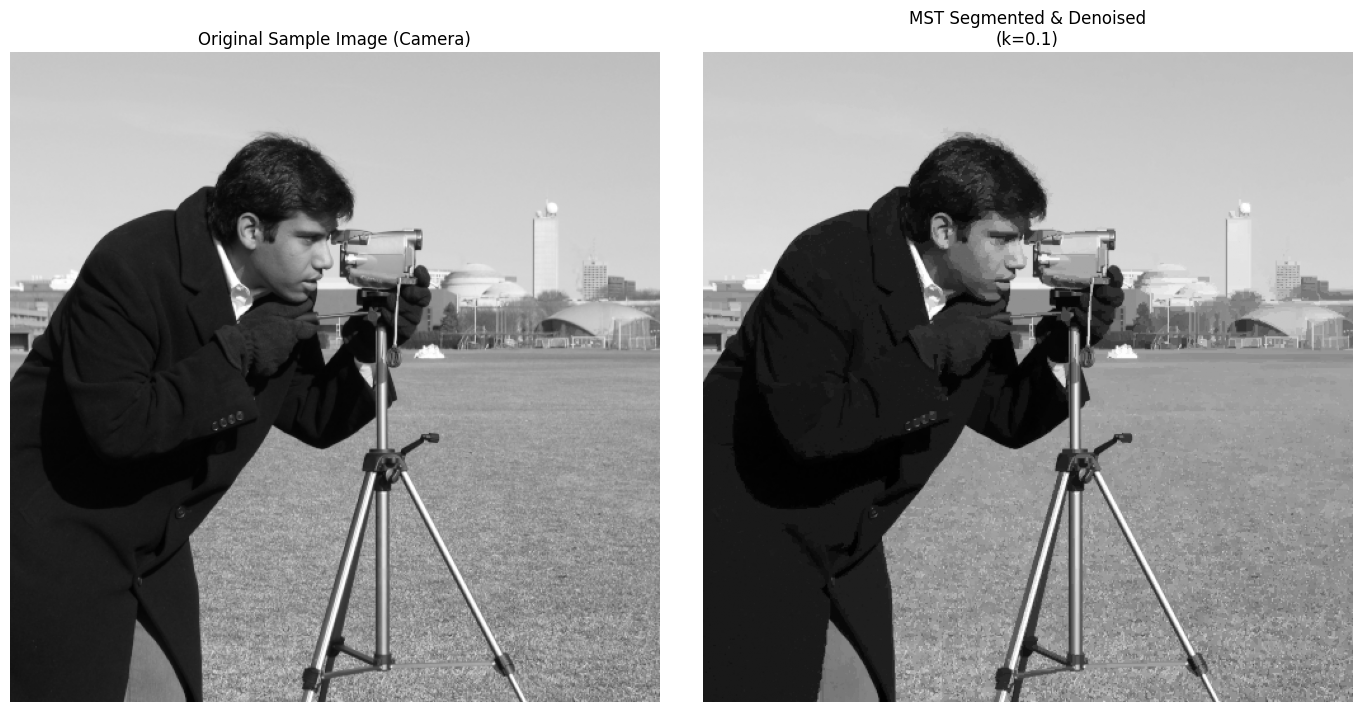

In [9]:

from skimage import data
img = img_as_float(data.camera())


K_PARAM = 0.1

print("Starting segmentation...")
start_time = time.time()


uf_components = segment_image_optimized(img, k=K_PARAM)
denoised_img = denoise_image(img, uf_components)

end_time = time.time()
compute_time = end_time - start_time

mse, psnr = calculate_metrics(img, denoised_img)
num_segments = len(set(uf_components.find(i) for i in range(img.size)))

print("-" * 30)
print("QUANTITATIVE METRICS")
print("-" * 30)
print(f"Computation Time: {compute_time:.4f} seconds")
print(f"Number of Segments: {num_segments}")
print(f"Mean Squared Error (MSE): {mse:.6f}")
print(f"Peak Signal-to-Noise Ratio (PSNR): {psnr:.2f} dB")
print("-" * 30)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original Sample Image (Camera)')
axes[0].axis('off')

axes[1].imshow(denoised_img, cmap='gray')
axes[1].set_title(f'MST Segmented & Denoised\n(k={K_PARAM})')
axes[1].axis('off')

plt.tight_layout()
plt.show()